In [2]:
import pandas as pd

df = pd.read_csv("data/brca_data_w_subtypes.csv")
print(df.shape)
print(df.columns[:10])
df.head()


(705, 1941)
Index(['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1',
       'rs_MUCL1', 'rs_GSTM1', 'rs_PIP', 'rs_ADIPOQ', 'rs_ADH1B'],
      dtype='object')


,rs_CLEC3A,rs_CPB1,rs_SCGB2A2,rs_SCGB1D2,rs_TFF1,rs_MUCL1,rs_GSTM1,rs_PIP,rs_ADIPOQ,rs_ADH1B,...,pp_p62.LCK.ligand,pp_p70S6K,pp_p70S6K.pT389,pp_p90RSK,pp_p90RSK.pT359.S363,vital.status,PR.Status,ER.Status,HER2.Final.Status,histological.type
0,0.892818,6.580103,14.123672,10.606501,13.189237,6.649466,10.520335,10.338490,10.248379,10.229970,...,-0.691766,-0.337863,-0.178503,0.011638,-0.207257,0,Positive,Positive,Negative,infiltrating ductal carcinoma
1,0.000000,3.691311,17.116090,15.517231,9.867616,9.691667,8.179522,7.911723,1.289598,1.818891,...,0.279067,0.292925,-0.155242,-0.089365,0.267530,0,Positive,Negative,Negative,infiltrating ductal carcinoma
2,3.748150,4.375255,9.658123,5.326983,12.109539,11.644307,10.517330,5.114925,11.975349,11.911437,...,0.219910,0.308110,-0.190794,-0.222150,-0.198518,0,Positive,Positive,Negative,infiltrating ductal carcinoma
3,0.000000,18.235519,18.535480,14.533584,14.078992,8.913760,10.557465,13.304434,8.205059,9.211476,...,-0.266554,-0.079871,-0.463237,0.522998,-0.046902,0,Positive,Positive,Negative,infiltrating ductal carcinoma
4,0.000000,4.583724,15.711865,12.804521,8.881669,8.430028,12.964607,6.806517,4.294341,5.385714,...,-0.441542,-0.152317,0.511386,-0.096482,0.037473,0,Positive,Positive,Negative,infiltrating ductal carcinoma


In [3]:
non_numeric = df.select_dtypes(include='object').columns
print("Non-numeric columns:")
print(non_numeric)


Non-numeric columns:
Index(['PR.Status', 'ER.Status', 'HER2.Final.Status', 'histological.type'], dtype='object')


In [4]:
print(df['ER.Status'].value_counts())


ER.Status
Positive                       414
Negative                       135
Not Performed                   27
Performed but Not Available      5
Indeterminate                    2
Name: count, dtype: int64


In [5]:
import numpy as np

# Filtering to only Positive/Negative ER status
df_clean = df[df['ER.Status'].isin(['Positive', 'Negative'])].copy()

# Drop other metadata columns 
df_clean = df_clean.drop(['PR.Status', 'HER2.Final.Status', 'histological.type'], axis=1)

# Split into features and labels
X = df_clean.drop('ER.Status', axis=1)
y = np.where(df_clean['ER.Status'] == 'Positive', 1, 0)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive samples:", y.sum())


X shape: (549, 1937)
y shape: (549,)
Positive samples: 414


In [7]:
from sklearn.preprocessing import StandardScaler

# Replacing any missing values (NaNs) with the feature median
X_filled = X.fillna(X.median())

# Scale (z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

print("Scaled data shape:", X_scaled.shape)
print("Mean of first 5 features:", X_scaled[:, :5].mean(axis=0))
print("Std of first 5 features:", X_scaled[:, :5].std(axis=0))


Scaled data shape: (549, 1937)
Mean of first 5 features: [-3.55918492e-17 -4.85343399e-17 -2.07079850e-16 -1.55309888e-16
  2.36200454e-16]
Std of first 5 features: [1. 1. 1. 1. 1.]


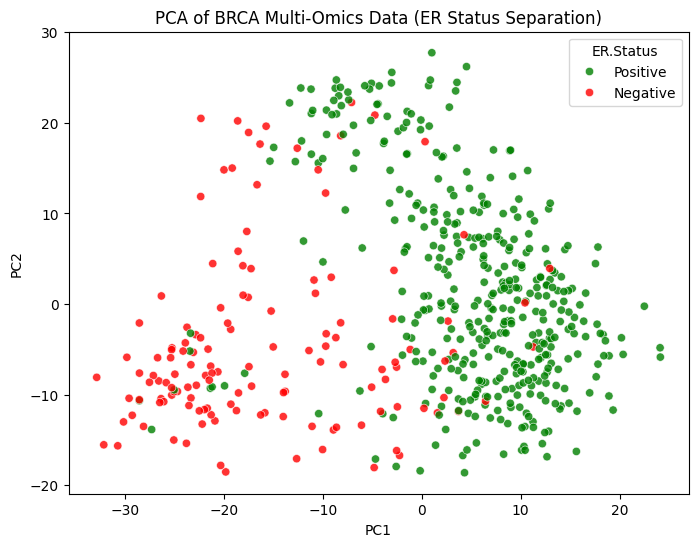

Explained variance ratio: [0.08278482 0.06188028]


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# dataframe for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'ER.Status': ['Positive' if val == 1 else 'Negative' for val in y]
})

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='ER.Status',
                palette={'Positive':'green','Negative':'red'}, alpha=0.8)
plt.title('PCA of BRCA Multi-Omics Data (ER Status Separation)')
plt.show()

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)


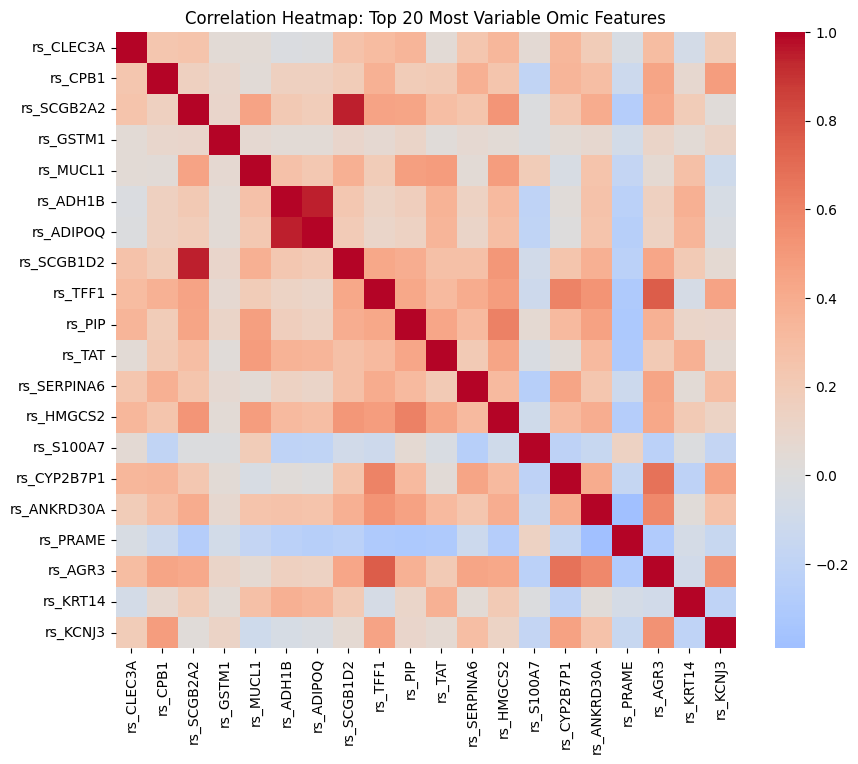

In [12]:
# Compute variance per feature
variances = X.var().sort_values(ascending=False)

# Select top 20 most variable features
top_features = variances.head(20).index

# Compute correlation matrix
corr = X[top_features].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: Top 20 Most Variable Omic Features")
plt.show()


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split data (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Train baseline model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Evaluate
y_pred = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Baseline Logistic Regression Accuracy:", round(acc, 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Baseline Logistic Regression Accuracy: 0.909

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        27
           1       0.94      0.94      0.94        83

    accuracy                           0.91       110
   macro avg       0.88      0.88      0.88       110
weighted avg       0.91      0.91      0.91       110



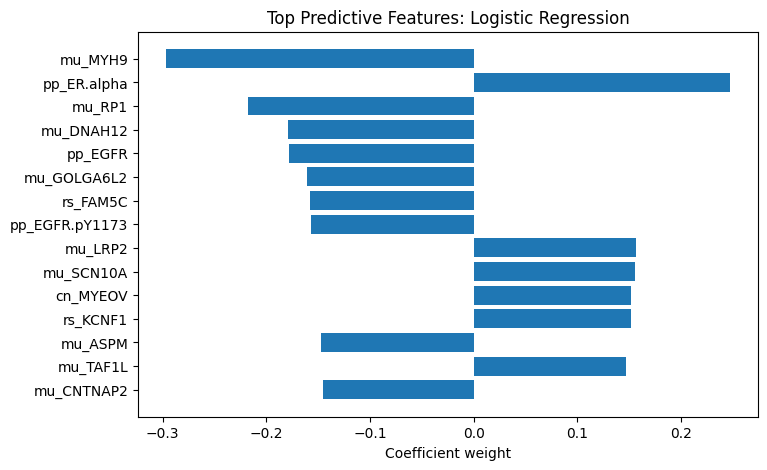

In [15]:
import numpy as np
coef = lr.coef_[0]
top_idx = np.argsort(np.abs(coef))[-15:][::-1]
top_features = X.columns[top_idx]
top_values = coef[top_idx]

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(top_features, top_values)
plt.gca().invert_yaxis()
plt.title("Top Predictive Features: Logistic Regression")
plt.xlabel("Coefficient weight")
plt.show()
